# Duplicate / Overlap BBox Fixer (Clean v1)
dup_df(`find_duplicate_bboxes_per_image`) 결과를 그대로 사용해 pair를 수정/삭제합니다.


In [1]:

# 0) Config
import os, json, random, shutil, datetime
from pathlib import Path

ANN_ROOT = Path("data/train_annotations")
IMG_ROOT = Path("data/train_images")

FILTER_DRUG_ID = None   # 예: "K-001900"

IOU_THR = 0.98
INCLUDE_EXACT = True
MAKE_BACKUP = True

print("ANN_ROOT:", ANN_ROOT)
print("IMG_ROOT:", IMG_ROOT)
print("FILTER_DRUG_ID:", FILTER_DRUG_ID)
print("IOU_THR:", IOU_THR)


ANN_ROOT: data\train_annotations
IMG_ROOT: data\train_images
FILTER_DRUG_ID: None
IOU_THR: 0.98


In [2]:

# 1) Utils
import pandas as pd
import numpy as np
import math

def norm_path(p: str) -> str:
    if p is None:
        return ""
    p = str(p).strip().replace("\\", "/")
    while "//" in p:
        p = p.replace("//", "/")
    return p

def make_image_key(file_name: str) -> str:
    # 같은 이미지를 항상 같은 key로 묶기: basename + lower
    p = norm_path(file_name)
    return os.path.basename(p).lower()

def bbox_xywh_to_xyxy(b):
    x,y,w,h = map(float, b)
    return (x, y, x+w, y+h)

def iou_xywh(b1, b2):
    ax1, ay1, ax2, ay2 = bbox_xywh_to_xyxy(b1)
    bx1, by1, bx2, by2 = bbox_xywh_to_xyxy(b2)
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    iw = max(0.0, inter_x2 - inter_x1)
    ih = max(0.0, inter_y2 - inter_y1)
    inter = iw * ih
    a_area = max(0.0, ax2-ax1) * max(0.0, ay2-ay1)
    b_area = max(0.0, bx2-bx1) * max(0.0, by2-by1)
    denom = a_area + b_area - inter
    if denom <= 0:
        return 0.0
    return float(inter / denom)

def safe_backup(path: Path):
    if not MAKE_BACKUP:
        return None
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    bak = path.with_suffix(path.suffix + f".bak_{ts}")
    shutil.copy2(path, bak)
    return bak

def resolve_image_path(file_name: str):
    """v2/v3에서 쓰던 방식 유지 + IMG_ROOT 타입 실수 방지 패치."""
    from pathlib import Path
    import os

    global IMG_ROOT
    # IMG_ROOT가 Path '타입'으로 잘못 들어간 경우(Path 자체)도 자동 복구
    if IMG_ROOT is Path:
        IMG_ROOT = Path("data/train_images")
    elif isinstance(IMG_ROOT, str):
        IMG_ROOT = Path(IMG_ROOT)
    else:
        try:
            IMG_ROOT = Path(IMG_ROOT)
        except Exception:
            IMG_ROOT = Path("data/train_images")

    fn = norm_path(file_name)
    base = os.path.basename(fn)

    cands = [IMG_ROOT / fn, IMG_ROOT / base]
    stem = os.path.splitext(base)[0]
    for ext in [".jpg",".jpeg",".png",".JPG",".JPEG",".PNG"]:
        cands.append(IMG_ROOT / (stem + ext))

    for p in cands:
        if p.exists():
            return p
    return None

print("utils loaded")


utils loaded


In [3]:

# 2) Scan JSONs -> USE_OBJ
def parse_drug_id_and_code(json_path: Path):
    # 파일명 예: K-001900-016548-019607-029451_0_2_0_2_70_000_200.json
    name = json_path.name
    drug_id = None
    drug_code = None

    if name.startswith("K-") and "_" in name:
        head = name.split("_")[0]
        parts = head.split("-")
        if len(parts) >= 2:
            drug_id = "-".join(parts[:2])   # K-001900
            rest = parts[2:]
            if rest:
                drug_code = "-".join(rest)  # 016548-...

    if drug_id is None:
        for p in json_path.parts[::-1]:
            if p.startswith("K-") and len(p) >= 7:
                drug_id = p
                break

    if drug_code is None and drug_id and name.startswith(drug_id + "-"):
        head = name.split("_")[0]
        drug_code = head[len(drug_id)+1:].lstrip("-")

    if drug_code and drug_code.startswith("K-"):
        drug_code = drug_code[2:]

    return drug_id, drug_code

def read_one_json(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    file_name = ""
    if isinstance(data, dict):
        if "images" in data and data["images"]:
            file_name = data["images"][0].get("file_name") or ""
        elif "image" in data and isinstance(data["image"], dict):
            file_name = data["image"].get("file_name") or ""
        elif "file_name" in data:
            file_name = data.get("file_name") or ""

    bbox = None
    category = None
    if isinstance(data, dict):
        if "annotations" in data and data["annotations"]:
            anno = data["annotations"][0]
            bbox = anno.get("bbox", None)
            category = anno.get("category_name", None) or anno.get("category", None)
        elif "bbox" in data:
            bbox = data.get("bbox")
            category = data.get("category_name", None) or data.get("category", None)
        elif "object" in data and isinstance(data["object"], dict):
            bbox = data["object"].get("bbox")
            category = data["object"].get("category_name", None) or data["object"].get("category", None)

    if bbox is None:
        return None

    if isinstance(bbox, dict) and all(k in bbox for k in ["x","y","w","h"]):
        bbox_xywh = [bbox["x"], bbox["y"], bbox["w"], bbox["h"]]
    else:
        bbox_xywh = list(bbox)

    if len(bbox_xywh) != 4:
        return None

    drug_id, drug_code = parse_drug_id_and_code(json_path)

    rec = {
        "json_path": str(json_path),
        "file_name": file_name,
        "image_key": make_image_key(file_name if file_name else json_path.name),
        "bbox_xywh": [float(x) for x in bbox_xywh],
        "category": category,
        "drug_id": drug_id,
        "drug_code": drug_code,
    }
    return rec

json_paths = list(ANN_ROOT.rglob("*.json"))
print("found json:", len(json_paths))

rows = []
for p in json_paths:
    rec = read_one_json(p)
    if rec is None:
        continue
    if FILTER_DRUG_ID and rec.get("drug_id") != FILTER_DRUG_ID:
        continue
    rows.append(rec)

USE_OBJ = rows
idx_df = pd.DataFrame(USE_OBJ)

print("USE_OBJ:", len(USE_OBJ))
print("images:", idx_df["image_key"].nunique() if len(idx_df) else 0)
display(idx_df.head(5))


found json: 763
USE_OBJ: 763
images: 232


,json_path,file_name,image_key,bbox_xywh,category,drug_id,drug_code
0,data\train_annotations\K-003544-004543-016548-...,K-003544-004543-016548-027993_0_2_0_2_70_000_2...,k-003544-004543-016548-027993_0_2_0_2_70_000_2...,"[619.0, 867.0, 217.0, 214.0]",None,K-003544,004543-016548-027993
1,data\train_annotations\K-003544-004543-016548-...,K-003544-004543-016548-027993_0_2_0_2_75_000_2...,k-003544-004543-016548-027993_0_2_0_2_75_000_2...,"[149.0, 188.0, 201.0, 199.0]",None,K-003544,004543-016548-027993
2,data\train_annotations\K-003544-004543-016548-...,K-003544-004543-016548-027993_0_2_0_2_90_000_2...,k-003544-004543-016548-027993_0_2_0_2_90_000_2...,"[162.0, 197.0, 211.0, 202.0]",None,K-003544,004543-016548-027993
3,data\train_annotations\K-003544-004543-016548-...,K-003544-004543-016548-027993_0_2_0_2_70_000_2...,k-003544-004543-016548-027993_0_2_0_2_70_000_2...,"[145.0, 868.0, 212.0, 210.0]",None,K-003544,004543-016548-027993
4,data\train_annotations\K-003544-004543-016548-...,K-003544-004543-016548-027993_0_2_0_2_75_000_2...,k-003544-004543-016548-027993_0_2_0_2_75_000_2...,"[602.0, 189.0, 205.0, 199.0]",None,K-003544,004543-016548-027993


In [4]:

# 3) dup_df 생성
def find_duplicate_bboxes_per_image(use_obj, iou_thr=0.98, include_exact=True):
    df = pd.DataFrame(use_obj).copy()
    if df.empty:
        return pd.DataFrame(columns=["image_key","iou","exact",
                                     "json_path_a","json_path_b","bbox_a","bbox_b",
                                     "drug_id_a","drug_id_b","drug_code_a","drug_code_b",
                                     "category_a","category_b","file_name_a","file_name_b"])
    df["file_name"] = df["file_name"].fillna("")
    df["image_key"] = df["image_key"].fillna(df["file_name"].apply(make_image_key))

    pairs = []
    for image_key, g in df.groupby("image_key", sort=False):
        g = g.reset_index(drop=True)
        if len(g) < 2:
            continue
        for i in range(len(g)):
            for j in range(i+1, len(g)):
                b1 = g.loc[i, "bbox_xywh"]
                b2 = g.loc[j, "bbox_xywh"]
                exact = bool(np.allclose(b1, b2))
                iou = iou_xywh(b1, b2)
                if (include_exact and exact) or (iou >= iou_thr):
                    pairs.append({
                        "image_key": image_key,
                        "iou": float(iou),
                        "exact": exact,
                        "json_path_a": g.loc[i, "json_path"],
                        "json_path_b": g.loc[j, "json_path"],
                        "bbox_a": b1,
                        "bbox_b": b2,
                        "drug_id_a": g.loc[i, "drug_id"],
                        "drug_id_b": g.loc[j, "drug_id"],
                        "drug_code_a": g.loc[i, "drug_code"],
                        "drug_code_b": g.loc[j, "drug_code"],
                        "category_a": g.loc[i, "category"],
                        "category_b": g.loc[j, "category"],
                        "file_name_a": g.loc[i, "file_name"],
                        "file_name_b": g.loc[j, "file_name"],
                    })
    dup_df = pd.DataFrame(pairs)
    if not dup_df.empty:
        dup_df["exact"] = dup_df["exact"].fillna(False).astype(bool)
        dup_df["iou"] = dup_df["iou"].fillna(0.0).astype(float)
        dup_df = dup_df.sort_values(["exact","iou"], ascending=[False, False]).reset_index(drop=True)
    return dup_df

dup_df = find_duplicate_bboxes_per_image(USE_OBJ, iou_thr=IOU_THR, include_exact=INCLUDE_EXACT)
print("dup_df rows:", len(dup_df))
display(dup_df.head(20))


dup_df rows: 0


""


In [5]:

# 4) Pair 시각화
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def draw_pair(row, show=True):
    img_path = resolve_image_path(row["file_name_a"]) or resolve_image_path(row["file_name_b"])
    fig, ax = plt.subplots(figsize=(10, 7))
    if img_path and img_path.exists():
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{row['image_key']} | IoU={row['iou']:.4f} | exact={row['exact']} | {img_path.name}")
    else:
        ax.set_title(f"{row['image_key']} | IoU={row['iou']:.4f} | exact={row['exact']} | (image not found)")
        ax.set_xlim(0, 1000); ax.set_ylim(1000, 0)

    def _add_bbox(b, label):
        x,y,w,h = map(float, b)
        rect = patches.Rectangle((x,y), w,h, linewidth=2, fill=False)
        ax.add_patch(rect)
        ax.text(x, y, label, fontsize=12, bbox=dict(facecolor="white", alpha=0.6))

    _add_bbox(row["bbox_a"], "A")
    _add_bbox(row["bbox_b"], "B")
    ax.axis("off")
    if show:
        plt.show()
    return fig, ax

if len(dup_df) > 0:
    draw_pair(dup_df.iloc[0])


In [6]:

# 5) JSON 저장(수정/삭제)
from pathlib import Path

def load_json(path_str: str):
    p = Path(path_str)
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)

def save_json(path_str: str, data):
    p = Path(path_str)
    if MAKE_BACKUP:
        safe_backup(p)
    with open(p, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

def update_bbox_in_json(path_str: str, new_bbox_xywh):
    data = load_json(path_str)
    updated = False
    if isinstance(data, dict) and "annotations" in data and data["annotations"]:
        if "bbox" in data["annotations"][0]:
            data["annotations"][0]["bbox"] = [float(x) for x in new_bbox_xywh]
            updated = True
    if not updated and isinstance(data, dict) and "bbox" in data:
        data["bbox"] = [float(x) for x in new_bbox_xywh]
        updated = True
    if not updated and isinstance(data, dict) and "object" in data and isinstance(data["object"], dict) and "bbox" in data["object"]:
        data["object"]["bbox"] = [float(x) for x in new_bbox_xywh]
        updated = True
    if not updated:
        raise KeyError(f"bbox field not found in {path_str}")
    save_json(path_str, data)

def delete_annotation_in_json(path_str: str):
    data = load_json(path_str)
    deleted = False
    if isinstance(data, dict) and "annotations" in data and data["annotations"]:
        data["annotations"].pop(0)
        deleted = True
    else:
        if isinstance(data, dict) and "bbox" in data:
            data["bbox"] = None
            deleted = True
        elif isinstance(data, dict) and "object" in data and isinstance(data["object"], dict) and "bbox" in data["object"]:
            data["object"]["bbox"] = None
            deleted = True
    if not deleted:
        raise KeyError(f"annotations/bbox field not found in {path_str}")
    save_json(path_str, data)


In [7]:
# 6) dup_df 기반 Pair Editor (dup_df row(pair) 그대로 편집)
import os
import ipywidgets as widgets
from IPython.display import display, clear_output

def _norm_path(p: str) -> str:
    if p is None:
        return ""
    return str(p).strip().replace("\\", "/")

def _parse_ids_from_json_path(json_path: str):
    """json_path에서 drug_id(K-xxxxxx) / drug_code(나머지) 를 최대한 안정적으로 추출"""
    p = _norm_path(json_path)
    base = os.path.basename(p)
    stem = os.path.splitext(base)[0]  # ..._200
    head = stem.split("_")[0]         # K-001900-016548-...
    parts = head.split("-")
    drug_id = ""
    drug_code = ""
    # 기대: ['K','001900', ...]
    if len(parts) >= 2 and parts[0].upper() == "K":
        drug_id = f"{parts[0]}-{parts[1]}"
        if len(parts) > 2:
            drug_code = "-".join(parts[2:])
    else:
        # 이미 K-001900 형태로 시작할 수도 있으니 fallback
        if head.startswith("K-") and len(parts) >= 2:
            drug_id = "-".join(parts[:2])
            if len(parts) > 2:
                drug_code = "-".join(parts[2:])
        else:
            drug_id = head
    return drug_id, drug_code, base

def _side_label(row, side: str) -> str:
    # dup_df에 drug_id_a가 'a'처럼 의미없는 값으로 들어오는 케이스를 방지:
    # -> json_path 기반으로 라벨 생성(가장 신뢰 가능)
    jp = row.get(f"json_path_{side}", "")
    did, dcode, jbase = _parse_ids_from_json_path(jp)
    # 너무 길면 code를 축약
    if dcode and len(dcode) > 32:
        dcode = dcode[:14] + "…" + dcode[-10:]
    parts = [x for x in [did, dcode, jbase] if x]
    return " | ".join(parts) if parts else side.upper()

if dup_df.empty:
    print("dup_df가 비어있습니다. (겹침 pair 없음) iou_thr를 낮춰보세요.")
else:
    # pair dropdown 라벨도 json_path 기반으로 더 직관적으로 표시
    def _pair_option(i, r):
        la = _side_label(r, "a")
        lb = _side_label(r, "b")
        return (f"[{i}] {r['image_key']} | IoU={float(r['iou']):.4f} | {la}  <->  {lb}", i)

    options = [_pair_option(i, r) for i, r in dup_df.iterrows()]
    pair_dd  = widgets.Dropdown(options=options, description="Pair", layout=widgets.Layout(width="95%"))
    which_dd = widgets.Dropdown(options=[("Edit A", "A"), ("Edit B", "B")], description="Edit")

    x = widgets.FloatText(description="x"); y = widgets.FloatText(description="y")
    w = widgets.FloatText(description="w"); h = widgets.FloatText(description="h")

    btn_load = widgets.Button(description="Load", button_style="")
    btn_save = widgets.Button(description="Save bbox", button_style="success")
    btn_del  = widgets.Button(description="Delete anno", button_style="danger")
    out = widgets.Output()

    _lock = {"busy": False}

    def _current_row():
        return dup_df.loc[pair_dd.value]

    def _update_edit_labels(row):
        labelA = _side_label(row, "a")
        labelB = _side_label(row, "b")
        which_dd.options = [(f"Edit {labelA}", "A"), (f"Edit {labelB}", "B")]

    def _fill_fields(row, which):
        b = row["bbox_a"] if which=="A" else row["bbox_b"]
        x.value, y.value, w.value, h.value = map(float, b)

    def _preview_draw(row):
        """현재 입력값(x,y,w,h)을 반영해 즉시 미리보기(저장은 아님)"""
        temp = dict(row)
        new_bbox = [float(x.value), float(y.value), float(w.value), float(h.value)]
        if which_dd.value == "A":
            temp["bbox_a"] = new_bbox
        else:
            temp["bbox_b"] = new_bbox
        with out:
            clear_output(wait=True)
            draw_pair(temp)
            target = row["json_path_a"] if which_dd.value=="A" else row["json_path_b"]
            print("Edit target:", _side_label(row, "a") if which_dd.value=="A" else _side_label(row, "b"))
            print("Target JSON:", target)
            print("Current bbox:", new_bbox)

    def on_load(_=None):
        if _lock["busy"]:
            return
        _lock["busy"] = True
        try:
            row = _current_row()
            _update_edit_labels(row)
            _fill_fields(row, which_dd.value)
            _preview_draw(row)
        finally:
            _lock["busy"] = False

    def on_save(_):
        row = _current_row()
        target = row["json_path_a"] if which_dd.value=="A" else row["json_path_b"]
        new_bbox = [float(x.value), float(y.value), float(w.value), float(h.value)]
        update_bbox_in_json(target, new_bbox)
        # dup_df도 즉시 갱신(다음 로드/프리뷰에 반영)
        if which_dd.value=="A":
            dup_df.at[pair_dd.value, "bbox_a"] = new_bbox
        else:
            dup_df.at[pair_dd.value, "bbox_b"] = new_bbox
        with out:
            print("✅ Saved:", target, "->", new_bbox)

    def on_del(_):
        row = _current_row()
        target = row["json_path_a"] if which_dd.value=="A" else row["json_path_b"]
        delete_annotation_in_json(target)
        with out:
            print("🗑️ Deleted annotation in:", target)
            print("Tip: 아래 셀에서 dup_df 재계산을 실행하세요.")

    # --- 실시간 프리뷰: 값이 바뀌면 즉시 redraw ---
    def _on_any_change(change):
        if _lock["busy"]:
            return
        row = _current_row()
        # pair 변경/which 변경 시: 필드를 해당 bbox로 재세팅 후 redraw
        if change["owner"] in (pair_dd, which_dd):
            _lock["busy"] = True
            try:
                _update_edit_labels(row)
                _fill_fields(row, which_dd.value)
            finally:
                _lock["busy"] = False
        _preview_draw(row)

    pair_dd.observe(_on_any_change, names="value")
    which_dd.observe(_on_any_change, names="value")
    for ww in (x, y, w, h):
        ww.observe(_on_any_change, names="value")

    btn_load.on_click(on_load)
    btn_save.on_click(on_save)
    btn_del.on_click(on_del)

    ui = widgets.VBox([
        pair_dd,
        widgets.HBox([which_dd, btn_load, btn_save, btn_del]),
        widgets.HBox([x,y,w,h]),
        out
    ])
    display(ui)

    # 첫 로드(자동)
    on_load()


dup_df가 비어있습니다. (겹침 pair 없음) iou_thr를 낮춰보세요.


In [8]:

# 7) 수정/삭제 후 dup_df 재계산
rows = []
for p in json_paths:
    rec = read_one_json(p)
    if rec is None:
        continue
    if FILTER_DRUG_ID and rec.get("drug_id") != FILTER_DRUG_ID:
        continue
    rows.append(rec)
USE_OBJ = rows
idx_df = pd.DataFrame(USE_OBJ)
dup_df = find_duplicate_bboxes_per_image(USE_OBJ, iou_thr=IOU_THR, include_exact=INCLUDE_EXACT)

print("recomputed dup_df rows:", len(dup_df))
display(dup_df.head(20))


recomputed dup_df rows: 0


""


In [10]:
# =========================
# 사용 예시 (특정 이미지 전체 bbox 오버레이)
# =========================

# 1) 파일명 전체로 찾기
# show_image_all_bboxes(idx_df, "K-001900-016548-019607-029451_0_2_0_2_70_000_200.jpg")

# 2) 파일명 일부(부분 문자열)로 찾기

# 3) image_key(=basename 소문자)로 찾기
# show_image_all_bboxes(idx_df, "k-001900-016548-019607-029451_0_2_0_2_70_000_200.jpg")


In [11]:
# =====================================================
# (ADD) 특정 이미지에 해당하는 전체 bbox 오버레이 확인
# - 기존 resolve_image_path(), norm_path() 재사용
# - query에 파일명 전체/일부(부분문자열) 모두 가능
# =====================================================

import os
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

def show_image_all_bboxes(idx_df: pd.DataFrame, query: str, *, show_labels: bool = True, max_show: int = 300):
    # image_key 보장 (v2 규칙: basename + lower)
    if "image_key" not in idx_df.columns:
        idx_df = idx_df.copy()
        idx_df["image_key"] = idx_df["file_name"].apply(lambda x: os.path.basename(norm_path(x)).lower())

    q = str(query).strip()
    q_key = os.path.basename(norm_path(q)).lower()

    # 1) image_key 정확 매칭 -> 2) file_name contains
    hit = idx_df[idx_df["image_key"] == q_key]
    if hit.empty:
        hit = idx_df[idx_df["file_name"].astype(str).str.contains(q, na=False)]

    if hit.empty:
        print(f"[NOT FOUND] query={query!r}")
        display(idx_df[["file_name","image_key"]].drop_duplicates().head(30))
        return

    # 여러 개 매칭되면 첫 번째 image_key로 고정
    target_key = hit["image_key"].iloc[0]
    rows = idx_df[idx_df["image_key"] == target_key].copy().reset_index(drop=True)

    # 이미지 경로: 기존 방식 그대로
    img_path = None
    for fn in rows["file_name"].astype(str).tolist():
        img_path = resolve_image_path(fn)
        if img_path:
            break

    if not img_path:
        print("[IMAGE NOT FOUND] resolve_image_path()로 이미지를 찾지 못했습니다.")
        display(rows[["file_name","image_key","json_path"]].head(20))
        return

    if "bbox_xywh" not in rows.columns:
        raise KeyError("idx_df에 'bbox_xywh' 컬럼이 없습니다. bbox 파싱 단계(Scan JSONs)를 먼저 확인하세요.")

    if len(rows) > max_show:
        rows = rows.iloc[:max_show].copy()

    img = Image.open(img_path).convert("RGB")
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img)
    ax.axis("off")

    def _to_xyxy(b):
        x, y, w, h = map(float, b)
        return x, y, x + w, y + h

    for i, r in rows.iterrows():
        x1, y1, x2, y2 = _to_xyxy(r["bbox_xywh"])
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2)
        ax.add_patch(rect)

        if show_labels:
            parts = []
            if "drug_id" in rows.columns and pd.notna(r.get("drug_id", None)):
                parts.append(str(r["drug_id"]))
            if "drug_code" in rows.columns and pd.notna(r.get("drug_code", None)):
                parts.append(str(r["drug_code"]))
            if "json_path" in rows.columns and pd.notna(r.get("json_path", None)):
                parts.append(os.path.basename(str(r["json_path"])))
            label = " | ".join(parts) if parts else f"#{i}"
            ax.text(x1, max(0, y1 - 4), label, fontsize=9, va="bottom")

    plt.show()

    cols = [c for c in ["file_name","image_key","drug_id","drug_code","category_name","bbox_xywh","json_path"] if c in rows.columns]
    display(rows[cols])

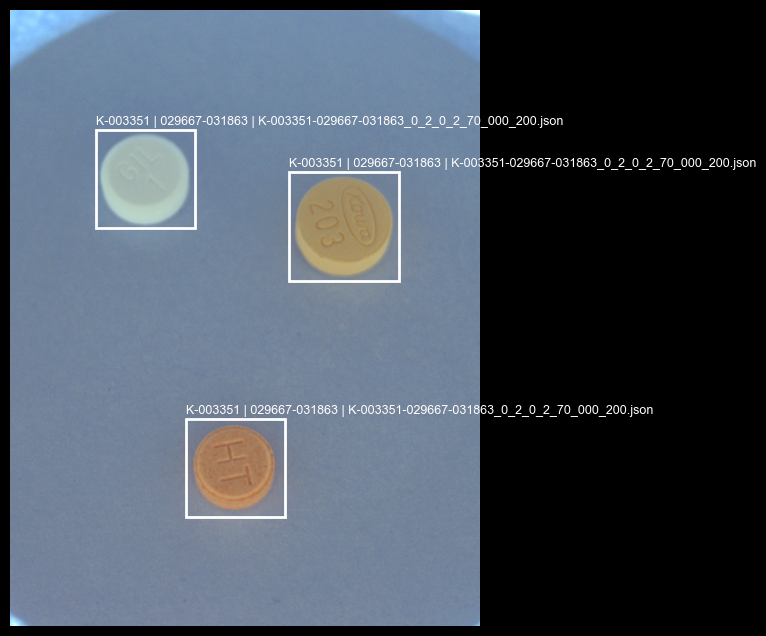

,file_name,image_key,drug_id,drug_code,bbox_xywh,json_path
0,K-003351-029667-031863_0_2_0_2_70_000_200.png,k-003351-029667-031863_0_2_0_2_70_000_200.png,K-003351,029667-031863,"[179.0, 249.0, 205.0, 203.0]",data\train_annotations\K-003351-029667-031863_...
1,K-003351-029667-031863_0_2_0_2_70_000_200.png,k-003351-029667-031863_0_2_0_2_70_000_200.png,K-003351,029667-031863,"[580.0, 336.0, 227.0, 227.0]",data\train_annotations\K-003351-029667-031863_...
2,K-003351-029667-031863_0_2_0_2_70_000_200.png,k-003351-029667-031863_0_2_0_2_70_000_200.png,K-003351,029667-031863,"[365.0, 850.0, 205.0, 203.0]",data\train_annotations\K-003351-029667-031863_...


In [13]:

# --- 사용 예시 ---
# show_image_all_bboxes(idx_df, "K-001900-016548-019607-029451_0_2_0_2_70_000_200.jpg")
# show_image_all_bboxes(idx_df, "K-001900-016548-019607-029451")  # 부분 문자열 가능
show_image_all_bboxes(idx_df, "k-003351-029667-031863_0_2_0_2_70_000_200.png")